In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

def simulate_two_photon_dicke(N, M, wc, wa, kappa_1, kappa_2, lam):
    """
    Simulates the driven-dissipative two-photon Dicke model.
    
    Parameters:
    N (int): Number of spins (system size)
    M (int): Cavity Fock space truncation
    wc (float): Cavity resonance frequency
    wa (float): Emitter resonance frequency
    kappa_1 (float): Single-photon loss rate
    kappa_2 (float): Two-photon loss rate
    lam (float): Light-matter coupling strength
    """
    # 1. Define the Hilbert space dimensions and operators
    j = N / 2.0
    dim_spin = int(2 * j + 1) # Size of the spin Hilbert space scales linearly [cite: 53]
    
    # Annihilation operator for the cavity mode
    a = qt.tensor(qt.destroy(M), qt.qeye(dim_spin))
    
    # Collective spin operators
    Jx = qt.tensor(qt.qeye(M), qt.jmat(j, 'x'))
    Jy = qt.tensor(qt.qeye(M), qt.jmat(j, 'y'))
    Jz = qt.tensor(qt.qeye(M), qt.jmat(j, 'z'))
    
    # 2. Construct the Hamiltonian
    # H = wc*a^dag a + (wa/2)*Jz + (lambda/N)*Jx*(a^dag^2 + a^2)
    H_cavity = wc * a.dag() * a
    H_atom = (wa / 2.0) * Jz
    H_int = (lam / N) * Jx * (a.dag()**2 + a**2)
    H = H_cavity + H_atom + H_int
    
    # 3. Construct the Lindblad Jump Operators (Collapse Operators)
    c_ops = []
    
    # Single-photon loss: L1 = sqrt(kappa_1) * a
    if kappa_1 > 0:
        L1 = np.sqrt(kappa_1) * a
        c_ops.append(L1)
        
    # Two-photon loss: L2 = sqrt(kappa_2 / N) * a^2
    if kappa_2 > 0:
        L2 = np.sqrt(kappa_2 / N) * (a**2)
        c_ops.append(L2)
        
    # 4. Diagonalize the Liouvillian to find the steady state (rho_ss)
    # QuTiP's steadystate solver builds the Liouvillian matrix and finds its zero eigenvector
    print('Finding rho')
    rho_ss = qt.steadystate(H, c_ops)
    
    # 5. Extract Observables
    # Average photon number scaled by N
    n_avg = qt.expect(a.dag() * a, rho_ss) / N
    
    # Average collective spin components scaled by N
    jx_avg = qt.expect(Jx, rho_ss) / N
    jz_avg = qt.expect(Jz, rho_ss) / N
    
    # Photon probability distribution P(n)
    # Trace out the spin degrees of freedom to get the reduced cavity density matrix
    rho_cavity = rho_ss.ptrace(0)
    P_n = rho_cavity.diag()
    
    return n_avg, jx_avg, jz_avg, P_n, rho_ss

# --- Execution and Plotting ---


"""
# Sweep coupling strength lambda
lambda_vals = np.linspace(0.0, 2.0, 20)
photons_ss = []

print("Simulating steady states...")
for lam in lambda_vals:
    n_avg, _, _, _ = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam)
    photons_ss.append(n_avg)

# Plotting the steady-state photon number vs coupling strength
plt.figure(figsize=(8, 5))
plt.plot(lambda_vals, photons_ss, marker='o', label=f'N={N_spins}, M={M_fock}')
plt.axvline(x=0.5, color='green', linestyle='--', label='Theoretical Critical Point')
plt.xlabel('Coupling Strength $\lambda / \omega_c$')
plt.ylabel('Average Photons $\langle a^\dagger a \\rangle / N$')
plt.title('Stabilized Dissipative Phase Transition')
plt.legend()
plt.grid(True)
plt.show()
"""

# Get the photon distribution P(n) at a strong coupling regime


'\n# Sweep coupling strength lambda\nlambda_vals = np.linspace(0.0, 2.0, 20)\nphotons_ss = []\n\nprint("Simulating steady states...")\nfor lam in lambda_vals:\n    n_avg, _, _, _ = simulate_two_photon_dicke(N_spins, M_fock, omega_c, omega_a, k1, k2, lam)\n    photons_ss.append(n_avg)\n\n# Plotting the steady-state photon number vs coupling strength\nplt.figure(figsize=(8, 5))\nplt.plot(lambda_vals, photons_ss, marker=\'o\', label=f\'N={N_spins}, M={M_fock}\')\nplt.axvline(x=0.5, color=\'green\', linestyle=\'--\', label=\'Theoretical Critical Point\')\nplt.xlabel(\'Coupling Strength $\\lambda / \\omega_c$\')\nplt.ylabel(\'Average Photons $\\langle a^\\dagger a \\rangle / N$\')\nplt.title(\'Stabilized Dissipative Phase Transition\')\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [3]:
def plot_wigner_function(rho_ss, x_max=15, points=200):
    """
    Calculates and plots the Wigner function for the cavity mode.
    
    Parameters:
    rho_ss: The steady-state density matrix of the full system.
    x_max: The limits for the X and P phase space axes.
    points: The resolution of the phase space grid.
    """
    # 1. Trace out the spins to get the cavity's reduced density matrix
    rho_cavity = rho_ss.ptrace(0)
    
    # 2. Define the phase space grid axes (X and P)
    # The paper plots from -15 to 15 
    xvec = np.linspace(-x_max, x_max, points)
    pvec = np.linspace(-x_max, x_max, points)
    
    # 3. Calculate the Wigner function
    W = qt.wigner(rho_cavity, xvec, pvec)
    w_max = np.max(np.abs(W))
    
    # 4. Plotting
    plt.figure(figsize=(6, 6))
    
    # Using 'Blues' colormap to match the style of Fig. 4 in the paper
    # vmin=0 ensures the white background maps to zero probability
    mesh = plt.pcolormesh(xvec, pvec, W, cmap='RdBu', shading='auto', vmin=-w_max, vmax=w_max)
    
    plt.xlabel('X')
    plt.ylabel('P')
    plt.title('Photonic Wigner Function')
    
    # Set ticks to match the paper's style (-15, 0, 15)
    plt.xticks([-x_max, 0, x_max])
    plt.yticks([-x_max, 0, x_max])
    plt.colorbar(mesh, label='Wigner Function $W(X,P)$')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# --- Example Usage (Using your previously fixed solver) ---

# Parameters matching Figure 4(b) from the paper


In [4]:
def simulate_qt_two_photon_only_even(N, M, wc, wa, kappa_2, lam, t_max, n_traj):
    """
    Simulates the two-photon Dicke model using Quantum Trajectories.
    """
    # 1. Define the Hilbert space dimensions and operators
    j = N / 2.0
    dim_spin = int(2 * j + 1)
    
    a = qt.tensor(qt.destroy(M), qt.qeye(dim_spin))
    Jx = qt.tensor(qt.qeye(M), qt.jmat(j, 'x'))
    Jz = qt.tensor(qt.qeye(M), qt.jmat(j, 'z'))
    
    # 2. Construct the Hamiltonian
    H_cavity = wc * a.dag() * a
    H_atom = (wa / 2.0) * Jz
    H_int = (lam / N) * Jx * (a.dag()**2 + a**2)
    H = H_cavity + H_atom + H_int
    
    # 3. Construct Jump Operator (Two-photon only)
    L2 = np.sqrt(kappa_2 / N) * (a**2)
    c_ops = [L2]
    
    # 4. Initialize the approximate steady-state density matrix
    rho_ss_approx = qt.tensor(qt.qzero(M), qt.qzero(dim_spin))
    M_adj = M // 2
    print(f"Running {n_traj} quantum trajectories...")
    
    # 5. Run Trajectories
    for i in range(n_traj):
        # Random initial state (Infinite temperature ensemble)
        n_cav = 2*np.random.randint(0, M_adj)
        n_spin = np.random.randint(0, dim_spin)
        psi0 = qt.tensor(qt.basis(M, n_cav), qt.basis(dim_spin, n_spin))
        
        # We only need the final state at t_max, so we pass a 2-element time list
        res = qt.mcsolve(H, psi0, [0, t_max], c_ops, ntraj=1, progress_bar=False)
        
        # CORRECTED: Grab the last state in the time evolution list
        psi_final = res.states[-1] 
        
        # Add outer product to our density matrix approximation
        rho_ss_approx += psi_final * psi_final.dag()
        
        # Optional: Print progress
        if (i + 1) % 50 == 0:
            print(f"Completed {i + 1}/{n_traj} trajectories")
            
    # 6. Average over all trajectories
    rho_ss_approx = rho_ss_approx / n_traj
    
    # Trace out the spins to get the reduced cavity density matrix
    rho_cavity = rho_ss_approx.ptrace(0)
    
    # Extract probability distribution P(n)
    P_n = rho_cavity.diag()
    
    return rho_cavity, P_n



In [5]:
def simulate_qt_two_photon_only_odd(N, M, wc, wa, kappa_2, lam, t_max, n_traj):
    """
    Simulates the two-photon Dicke model using Quantum Trajectories.
    """
    # 1. Define the Hilbert space dimensions and operators
    j = N / 2.0
    dim_spin = int(2 * j + 1)
    
    a = qt.tensor(qt.destroy(M), qt.qeye(dim_spin))
    Jx = qt.tensor(qt.qeye(M), qt.jmat(j, 'x'))
    Jz = qt.tensor(qt.qeye(M), qt.jmat(j, 'z'))
    
    # 2. Construct the Hamiltonian
    H_cavity = wc * a.dag() * a
    H_atom = (wa / 2.0) * Jz
    H_int = (lam / N) * Jx * (a.dag()**2 + a**2)
    H = H_cavity + H_atom + H_int
    
    # 3. Construct Jump Operator (Two-photon only)
    L2 = np.sqrt(kappa_2 / N) * (a**2)
    c_ops = [L2]
    
    # 4. Initialize the approximate steady-state density matrix
    rho_ss_approx = qt.tensor(qt.qzero(M), qt.qzero(dim_spin))
    M_adj = M // 2
    
    print(f"Running {n_traj} quantum trajectories...")
    
    # 5. Run Trajectories
    for i in range(n_traj):
        # Random initial state (Infinite temperature ensemble)
        n_cav = 2*np.random.randint(0, M_adj) + 1
        n_spin = np.random.randint(0, dim_spin)
        psi0 = qt.tensor(qt.basis(M, n_cav), qt.basis(dim_spin, n_spin))
        
        # We only need the final state at t_max, so we pass a 2-element time list
        res = qt.mcsolve(H, psi0, [0, t_max], c_ops, ntraj=1, progress_bar=False)
        
        # CORRECTED: Grab the last state in the time evolution list
        psi_final = res.states[-1] 
        
        # Add outer product to our density matrix approximation
        rho_ss_approx += psi_final * psi_final.dag()
        
        # Optional: Print progress
        if (i + 1) % 50 == 0:
            print(f"Completed {i + 1}/{n_traj} trajectories")
            
    # 6. Average over all trajectories
    rho_ss_approx = rho_ss_approx / n_traj
    
    # Trace out the spins to get the reduced cavity density matrix
    rho_cavity = rho_ss_approx.ptrace(0)
    
    # Extract probability distribution P(n)
    P_n = rho_cavity.diag()
    
    return rho_cavity, P_n



Running 700 quantum trajectories...
Completed 50/700 trajectories
Completed 100/700 trajectories
Completed 150/700 trajectories
Completed 200/700 trajectories
Completed 250/700 trajectories
Completed 300/700 trajectories
Completed 350/700 trajectories
Completed 400/700 trajectories
Completed 450/700 trajectories
Completed 500/700 trajectories
Completed 550/700 trajectories
Completed 600/700 trajectories
Completed 650/700 trajectories
Completed 700/700 trajectories


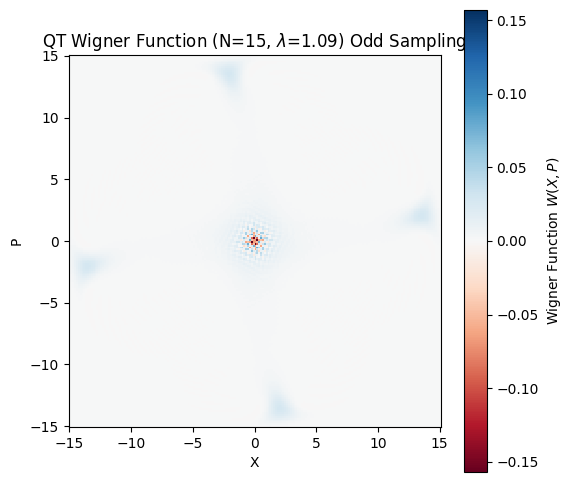

In [17]:
# --- Execution Parameters ---
N_spins = 15        # Now we can handle larger N
M_fock = 120         # Cavity truncation
omega_c = 1.0
omega_a = 1.0
k2 = 0.05           # Pure two-photon loss
lam_val = 1.09      # Coupling strength
t_max = 70.0        # Time to reach steady state (tune based on dynamics)
n_traj = 700        # Number of trajectories (Paper uses 500 to 3000)

# Run the simulation
rho_cavity_qt_odd_120, P_n_qt_odd = simulate_qt_two_photon_only_odd(
    N_spins, M_fock, omega_c, omega_a, k2, lam_val, t_max, n_traj
)

# You can now pass rho_cavity_qt directly to your existing plot_wigner_function
# Because plot_wigner_function in your notebook expects the full rho_ss and traces it, 
# you can temporarily modify it to accept rho_cavity directly:
xvec = np.linspace(-15, 15, 200)
W = qt.wigner(rho_cavity_qt_odd_120, xvec, xvec)
w_max = np.max(np.abs(W))

plt.figure(figsize=(6, 6))

# 2. Remove vmin=0 and use symmetric bounds for the RdBu colormap
mesh = plt.pcolormesh(xvec, xvec, W, cmap='RdBu', shading='auto', vmin=-w_max, vmax=w_max)

plt.xlabel('X')
plt.ylabel('P')
plt.title(f'QT Wigner Function (N={N_spins}, $\\lambda$={lam_val}) Odd Sampling')

# 3. Call plt.colorbar() and pass the mesh object to it
plt.colorbar(mesh, label='Wigner Function $W(X,P)$')

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

qt.qsave(rho_cavity_qt_odd_120,r'C:\Users\genes\Documents\Studium\FS26\Master Thesis\Code\Plots\Two_photon_dicke_2p_jump\Plot_Data\TPDT_N15_M120_l109_t70_n700_O')


Running 700 quantum trajectories...
Completed 50/700 trajectories
Completed 100/700 trajectories
Completed 150/700 trajectories
Completed 200/700 trajectories
Completed 250/700 trajectories
Completed 300/700 trajectories
Completed 350/700 trajectories
Completed 400/700 trajectories
Completed 450/700 trajectories
Completed 500/700 trajectories
Completed 550/700 trajectories
Completed 600/700 trajectories
Completed 650/700 trajectories
Completed 700/700 trajectories


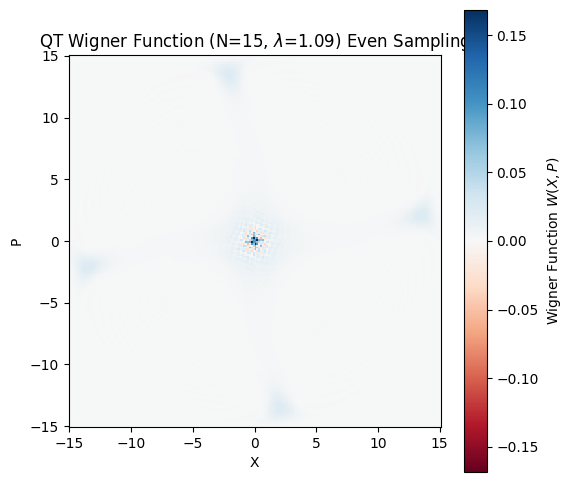

In [18]:
# --- Execution Parameters ---
N_spins = 15        # Now we can handle larger N
M_fock = 120         # Cavity truncation
omega_c = 1.0
omega_a = 1.0
k2 = 0.05           # Pure two-photon loss
lam_val = 1.09      # Coupling strength
t_max = 70.0        # Time to reach steady state (tune based on dynamics)
n_traj = 700        # Number of trajectories (Paper uses 500 to 3000)

# Run the simulation
rho_cavity_qt_even_120, P_n_qt_even = simulate_qt_two_photon_only_even(
    N_spins, M_fock, omega_c, omega_a, k2, lam_val, t_max, n_traj
)

# You can now pass rho_cavity_qt directly to your existing plot_wigner_function
# Because plot_wigner_function in your notebook expects the full rho_ss and traces it, 
# you can temporarily modify it to accept rho_cavity directly:
xvec = np.linspace(-15, 15, 200)
W = qt.wigner(rho_cavity_qt_even_120, xvec, xvec)
w_max = np.max(np.abs(W))

plt.figure(figsize=(6, 6))

# 2. Remove vmin=0 and use symmetric bounds for the RdBu colormap
mesh = plt.pcolormesh(xvec, xvec, W, cmap='RdBu', shading='auto', vmin=-w_max, vmax=w_max)

plt.xlabel('X')
plt.ylabel('P')
plt.title(f'QT Wigner Function (N={N_spins}, $\\lambda$={lam_val}) Even Sampling')

# 3. Call plt.colorbar() and pass the mesh object to it
plt.colorbar(mesh, label='Wigner Function $W(X,P)$')

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

qt.qsave(rho_cavity_qt_even_120,r'C:\Users\genes\Documents\Studium\FS26\Master Thesis\Code\Plots\Two_photon_dicke_2p_jump\Plot_Data\TPDT_N15_M120_l109_t70_n700_E')
